# Final Results Analysis

Compares the four optimizers benchmarked in `final-results/` — **ifBO** (the
flagship in-context freeze-thaw BO optimizer), **ifBO (random selection)** (an
ablation that disables ifBO's acquisition-based candidate selection), **SMAC
(BO+HB)**, and **Random Search** — across the four practice datasets
(`ag_news`, `amazon`, `dbpedia`, `imdb`). Each run is a 20-trial HPO search
over the `sequence-dl` (BiLSTM) search space.

Each `final-results/<dataset>_<optimizer>.jsonl` file is a
`history.log.jsonl`-style trial log: one JSON object per completed trial with
its sampled `config`, `budget` (epochs trained), `val_error`, `timestamp`, and
per-epoch `epoch_history`.

In [1]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

RESULTS_DIR = Path("final-results")

DATASETS = {
    "ag": "AG News",
    "amzn": "Amazon",
    "db": "DBpedia",
    "imdb": "IMDB",
}

OPTIMIZERS = {
    "ifbo": "ifBO",
    "smac": "SMAC (BO+HB)",
    "random": "Random Search",
    "ifbo_random": "ifBO (random selection)",
}

# Fixed categorical color per optimizer (entity), used unchanged across every
# chart below -- never re-cycled or reassigned per figure.
COLORS = {
    "ifbo": "#2a78d6",  # blue
    "smac": "#eb6834",  # orange
    "random": "#1baf7a",  # aqua
    "ifbo_random": "#eda100",  # yellow
}

## Load trial histories

In [2]:
TIMESTAMP_FMT = "%Y%m%d_%H%M%S,%f"


def load_trials(path: Path) -> list[dict]:
    trials = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                trials.append(json.loads(line))
    return trials


def parse_stem(stem: str) -> tuple[str, str]:
    for ds_key in DATASETS:
        if stem.startswith(ds_key + "_"):
            opt_key = stem[len(ds_key) + 1 :]
            if opt_key in OPTIMIZERS:
                return ds_key, opt_key
    raise ValueError(f"Could not parse dataset/optimizer from stem {stem!r}")


raw_trials: dict[tuple[str, str], list[dict]] = {}
rows = []

for path in sorted(RESULTS_DIR.glob("*.jsonl")):
    ds_key, opt_key = parse_stem(path.stem)
    trials = load_trials(path)
    trials.sort(key=lambda t: datetime.strptime(t["timestamp"], TIMESTAMP_FMT))
    raw_trials[(ds_key, opt_key)] = trials

    t0 = datetime.strptime(trials[0]["timestamp"], TIMESTAMP_FMT)
    running_best = float("inf")
    for t in trials:
        ts = datetime.strptime(t["timestamp"], TIMESTAMP_FMT)
        running_best = min(running_best, t["val_error"])
        rows.append(
            {
                "dataset": ds_key,
                "optimizer": opt_key,
                "trialNo": t["trialNo"],
                "budget": t["budget"],
                "execution_time": t["execution_time"],
                "wallclock_s": (ts - t0).total_seconds(),
                "val_error": t["val_error"],
                "val_accuracy": 1.0 - t["val_error"],
                "best_val_accuracy_so_far": 1.0 - running_best,
            }
        )

trials_df = pd.DataFrame(rows)
trials_df["dataset_label"] = trials_df["dataset"].map(DATASETS)
trials_df["optimizer_label"] = trials_df["optimizer"].map(OPTIMIZERS)
trials_df.head()

,dataset,optimizer,trialNo,budget,execution_time,wallclock_s,val_error,val_accuracy,best_val_accuracy_so_far,dataset_label,optimizer_label
0,ag,ifbo,1,5.0,70.526145,0.000000,0.7500,0.2500,0.2500,AG News,ifBO
1,ag,ifbo,2,5.0,174.835041,176.333736,0.2435,0.7565,0.7565,AG News,ifBO
2,ag,ifbo,3,8.0,105.642583,283.719731,0.2370,0.7630,0.7630,AG News,ifBO
3,ag,ifbo,4,5.0,185.364818,470.781416,0.7500,0.2500,0.7630,AG News,ifBO
4,ag,ifbo,5,5.0,54.964712,528.866625,0.0940,0.9060,0.9060,AG News,ifBO


## 1. Best validation accuracy vs. wallclock time

Faint dots are individual trials; the step line is the running best-so-far
incumbent within that run.

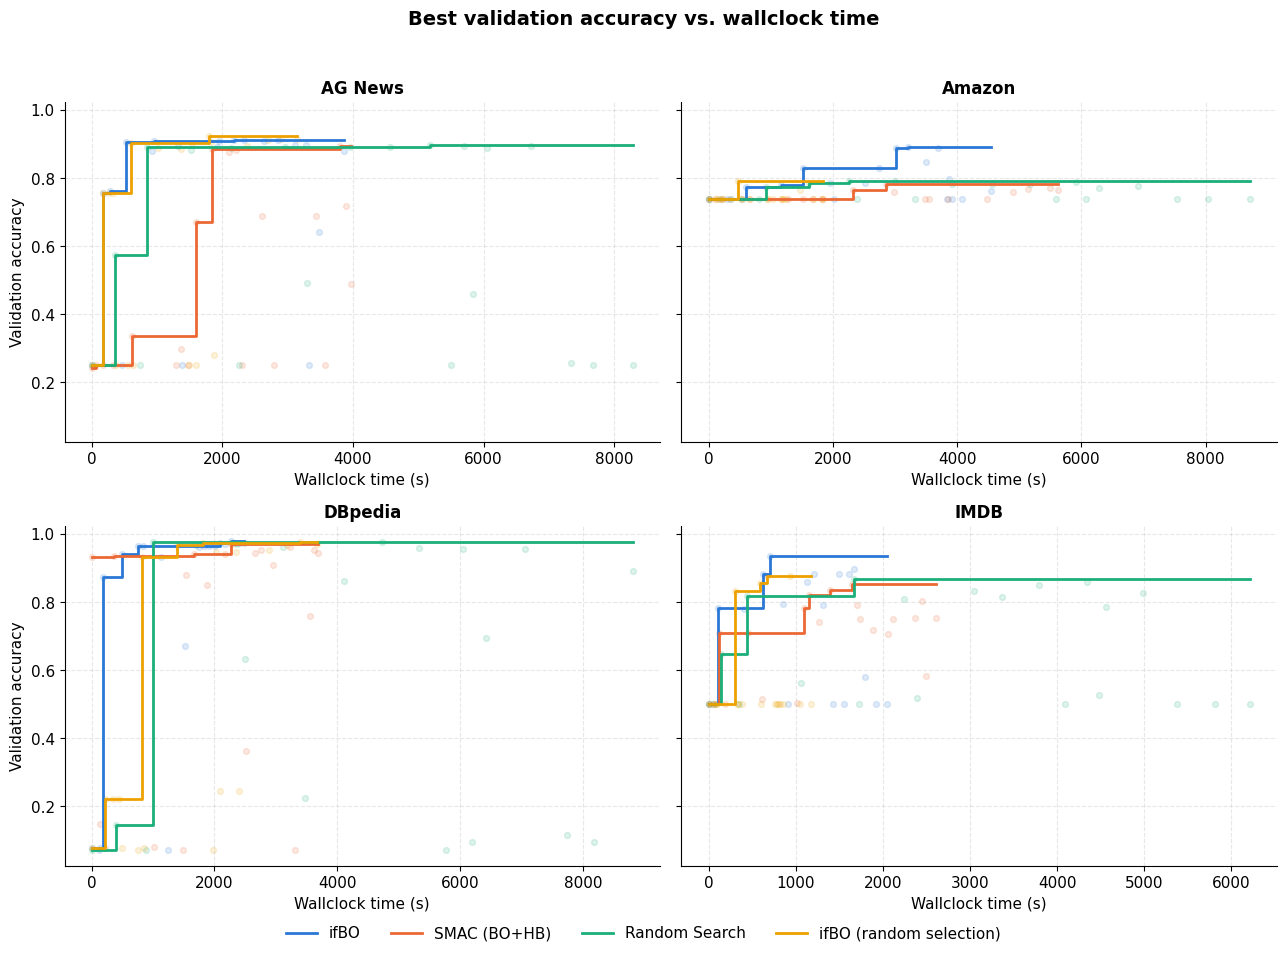

In [3]:
def plot_best_so_far(df, x_col, x_label, title, log_x=False):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
    for ax, (ds_key, ds_label) in zip(axes.flat, DATASETS.items()):
        sub_ds = df[df["dataset"] == ds_key]
        for opt_key, opt_label in OPTIMIZERS.items():
            sub = sub_ds[sub_ds["optimizer"] == opt_key].sort_values(x_col)
            if sub.empty:
                continue
            color = COLORS[opt_key]
            ax.scatter(
                sub[x_col], sub["val_accuracy"], color=color, alpha=0.15, s=18, zorder=1
            )
            ax.step(
                sub[x_col],
                sub["best_val_accuracy_so_far"],
                where="post",
                color=color,
                linewidth=2.0,
                label=opt_label,
                zorder=2,
            )
        ax.set_title(ds_label, fontsize=12, fontweight="bold")
        ax.set_xlabel(x_label)
        if log_x:
            ax.set_xscale("log")
    for ax in axes[:, 0]:
        ax.set_ylabel("Validation accuracy")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03), frameon=False)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    return fig


_ = plot_best_so_far(
    trials_df, "wallclock_s", "Wallclock time (s)", "Best validation accuracy vs. wallclock time"
)
plt.show()

## 2. Best validation accuracy vs. trial number

Since optimizers spend differing amounts of wallclock time per trial
(different fidelity schedules), comparing progress per-trial isolates
*sample efficiency* from raw speed.

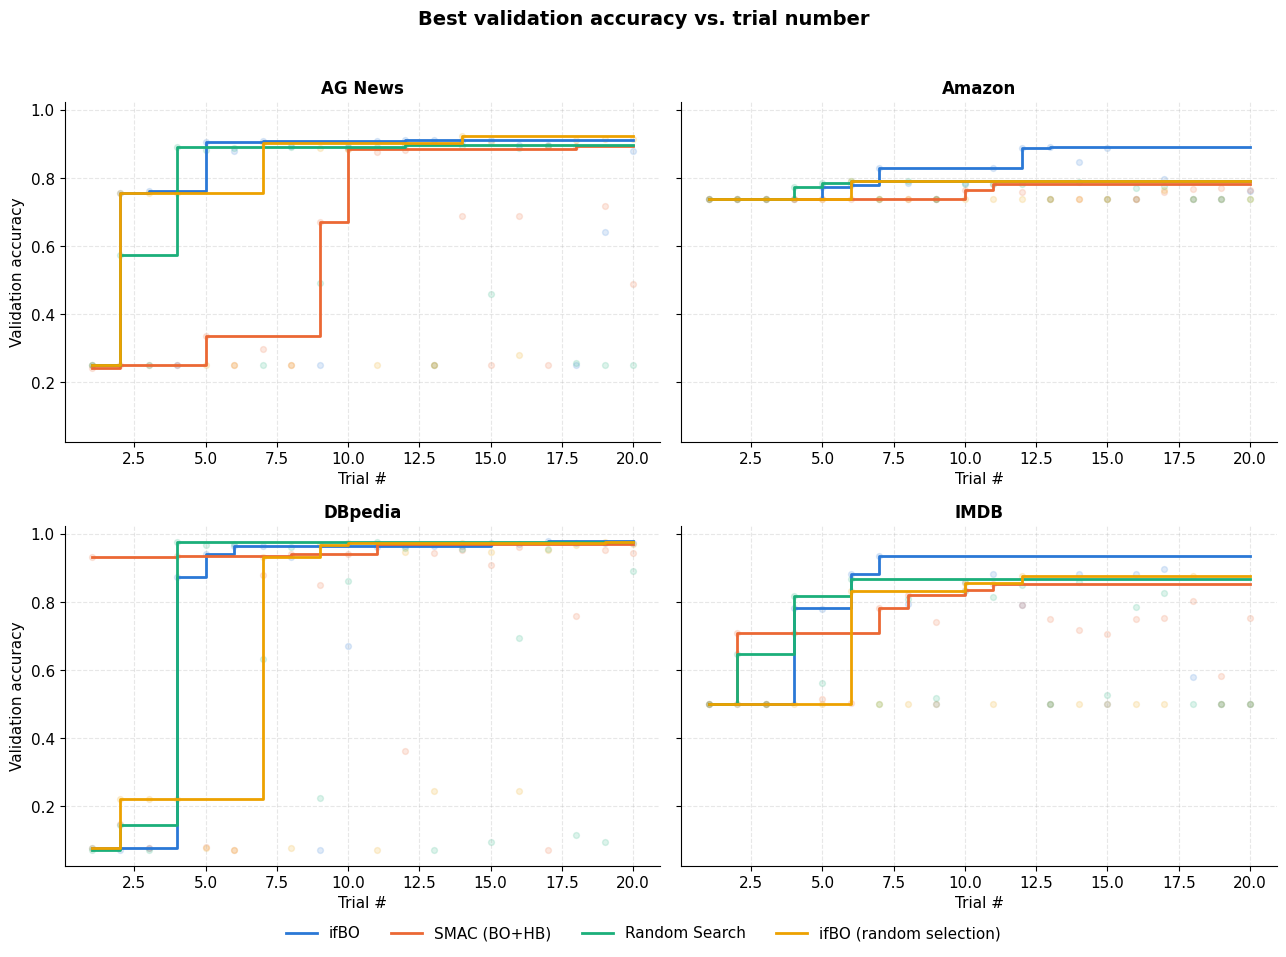

In [4]:
_ = plot_best_so_far(
    trials_df, "trialNo", "Trial #", "Best validation accuracy vs. trial number"
)
plt.show()

## 3. Final best accuracy — summary

In [5]:
final_acc = (
    trials_df.groupby(["dataset", "optimizer"])["val_accuracy"]
    .max()
    .unstack("optimizer")[list(OPTIMIZERS)]
)
final_acc.index = final_acc.index.map(DATASETS)
final_acc.columns = final_acc.columns.map(OPTIMIZERS)
final_acc

optimizer,ifBO,SMAC (BO+HB),Random Search,ifBO (random selection)
dataset,,,,
AG News,0.9135,0.8935,0.8965,0.9245
Amazon,0.8915,0.7820,0.7925,0.7930
DBpedia,0.9785,0.9700,0.9780,0.9770
IMDB,0.9355,0.8525,0.8670,0.8770


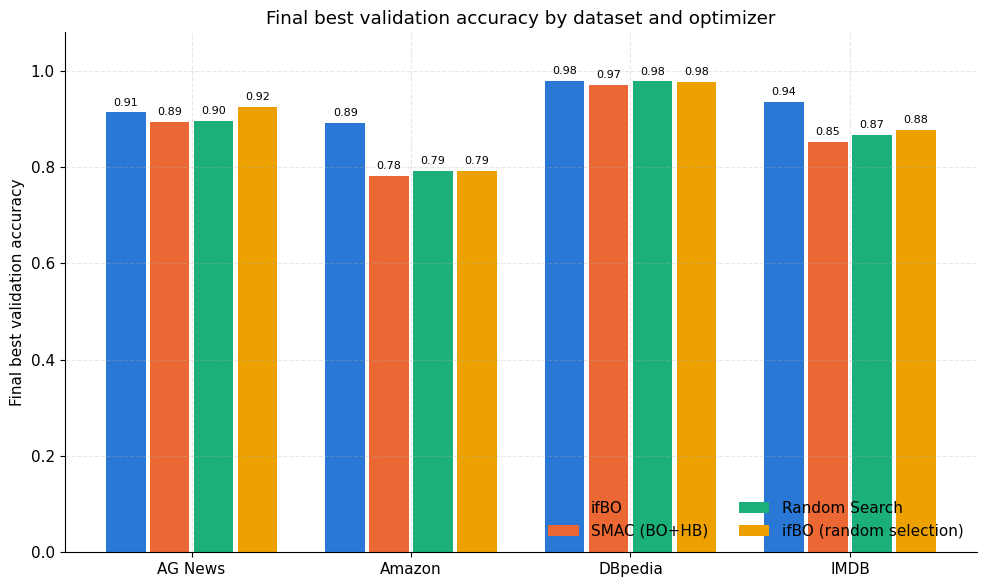

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
n_opt = len(OPTIMIZERS)
x = np.arange(len(final_acc.index))
width = 0.8 / n_opt

for i, (opt_key, opt_label) in enumerate(OPTIMIZERS.items()):
    vals = final_acc[opt_label]
    offset = x + i * width - 0.4 + width / 2
    ax.bar(offset, vals, width=width * 0.9, color=COLORS[opt_key], label=opt_label)
    for xi, v in zip(offset, vals):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(final_acc.index)
ax.set_ylabel("Final best validation accuracy")
ax.set_ylim(0, 1.08)
ax.set_title("Final best validation accuracy by dataset and optimizer")
ax.legend(loc="lower right", ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## 4. Heatmap of final accuracy (dataset × optimizer)

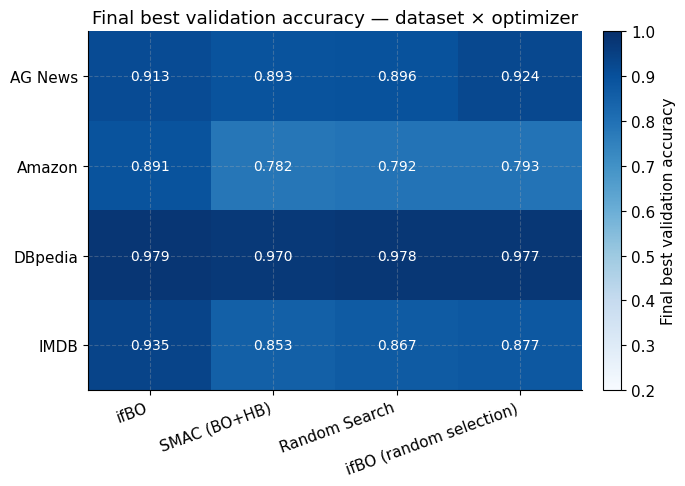

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
data = final_acc.values
im = ax.imshow(data, cmap="Blues", vmin=0.2, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(final_acc.columns)))
ax.set_xticklabels(final_acc.columns, rotation=20, ha="right")
ax.set_yticks(range(len(final_acc.index)))
ax.set_yticklabels(final_acc.index)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        text_color = "white" if v > 0.65 else "#2b2b28"
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", color=text_color, fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Final best validation accuracy")
ax.set_title("Final best validation accuracy — dataset × optimizer")
fig.tight_layout()
plt.show()

## 5. Per-trial accuracy distribution (exploration spread)

Boxplots (with jittered raw points) of every *sampled* trial's validation
accuracy per optimizer, per dataset -- not just the incumbent. A tighter,
higher distribution means the optimizer is spending its budget on
consistently good configs rather than wasting trials on poor ones.

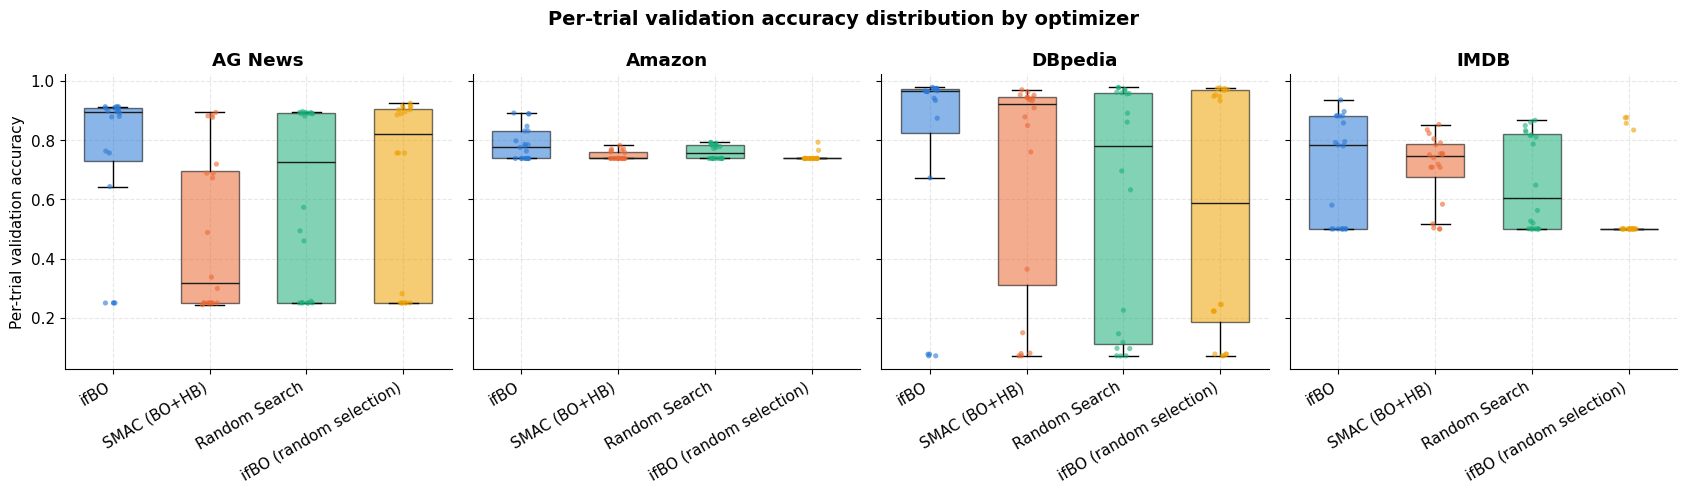

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(17, 5), sharey=True)
rng = np.random.default_rng(0)

for ax, (ds_key, ds_label) in zip(axes, DATASETS.items()):
    sub_ds = trials_df[trials_df["dataset"] == ds_key]
    data = [sub_ds[sub_ds["optimizer"] == opt_key]["val_accuracy"].values for opt_key in OPTIMIZERS]

    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False)
    for patch, opt_key in zip(bp["boxes"], OPTIMIZERS):
        patch.set_facecolor(COLORS[opt_key])
        patch.set_alpha(0.55)
    for median in bp["medians"]:
        median.set_color("#1a1a19")

    for i, opt_key in enumerate(OPTIMIZERS, start=1):
        pts = sub_ds[sub_ds["optimizer"] == opt_key]["val_accuracy"].values
        jitter = rng.uniform(-0.08, 0.08, size=len(pts))
        ax.scatter(
            np.full(len(pts), i) + jitter, pts, color=COLORS[opt_key], s=14, alpha=0.6, zorder=3, edgecolor="none"
        )

    ax.set_xticks(range(1, len(OPTIMIZERS) + 1))
    ax.set_xticklabels(list(OPTIMIZERS.values()), rotation=30, ha="right")
    ax.set_title(ds_label, fontweight="bold")

axes[0].set_ylabel("Per-trial validation accuracy")
fig.suptitle("Per-trial validation accuracy distribution by optimizer", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 6. Fidelity (epoch budget) allocated per trial

Shows each optimizer's multi-fidelity behavior: Random Search trains every
trial for a fixed epoch budget, while SMAC (Hyperband rungs) and ifBO
(continuous freeze-thaw) adaptively allocate more epochs to promising
configs.

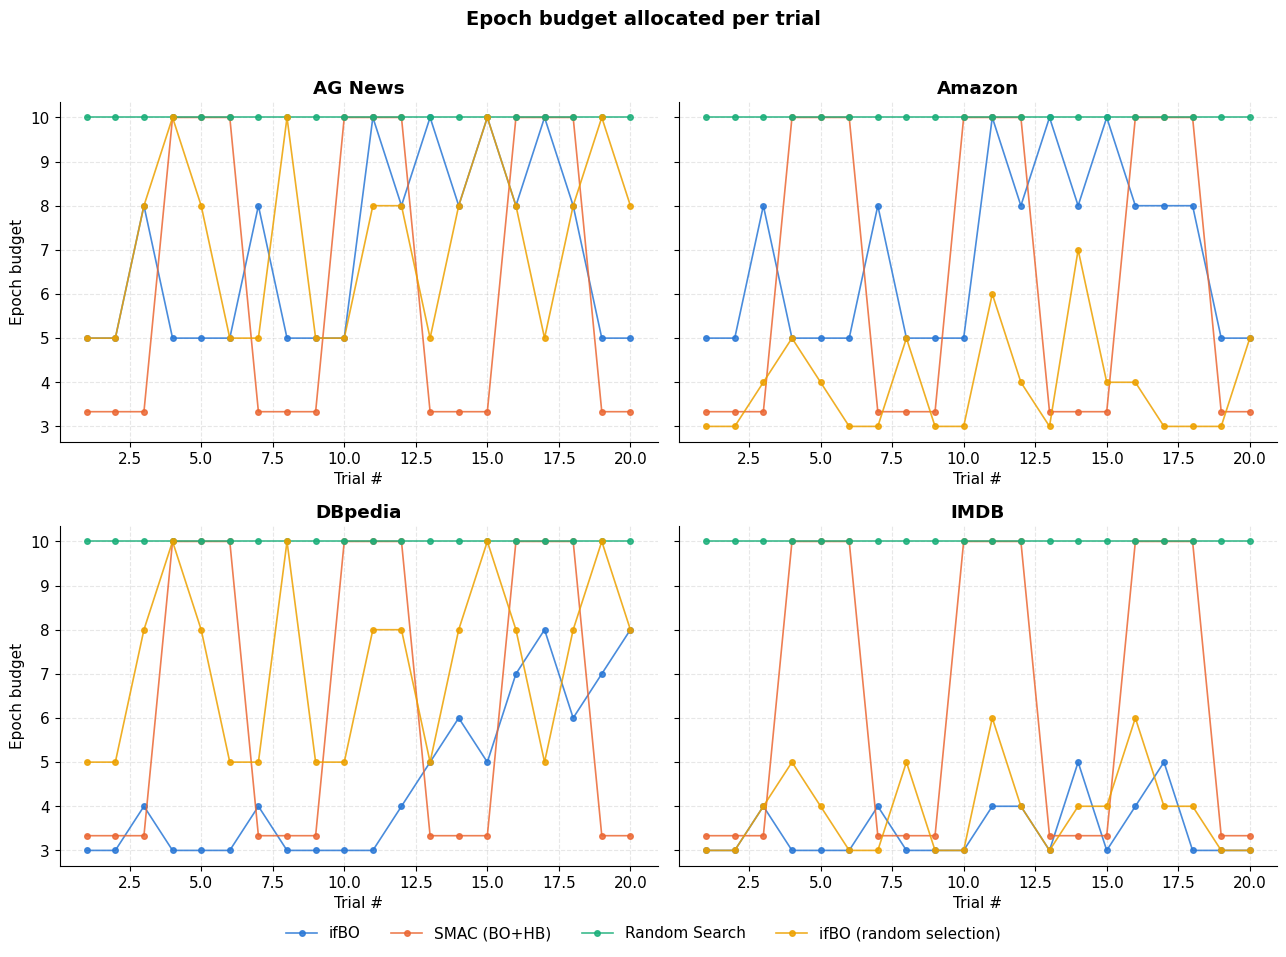

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
for ax, (ds_key, ds_label) in zip(axes.flat, DATASETS.items()):
    sub_ds = trials_df[trials_df["dataset"] == ds_key]
    for opt_key, opt_label in OPTIMIZERS.items():
        sub = sub_ds[sub_ds["optimizer"] == opt_key].sort_values("trialNo")
        ax.plot(
            sub["trialNo"], sub["budget"], "o-", color=COLORS[opt_key],
            markersize=4, linewidth=1.2, alpha=0.85, label=opt_label,
        )
    ax.set_title(ds_label, fontweight="bold")
    ax.set_xlabel("Trial #")

for ax in axes[:, 0]:
    ax.set_ylabel("Epoch budget")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03), frameon=False)
fig.suptitle("Epoch budget allocated per trial", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 7. Training curves for each optimizer's best trial

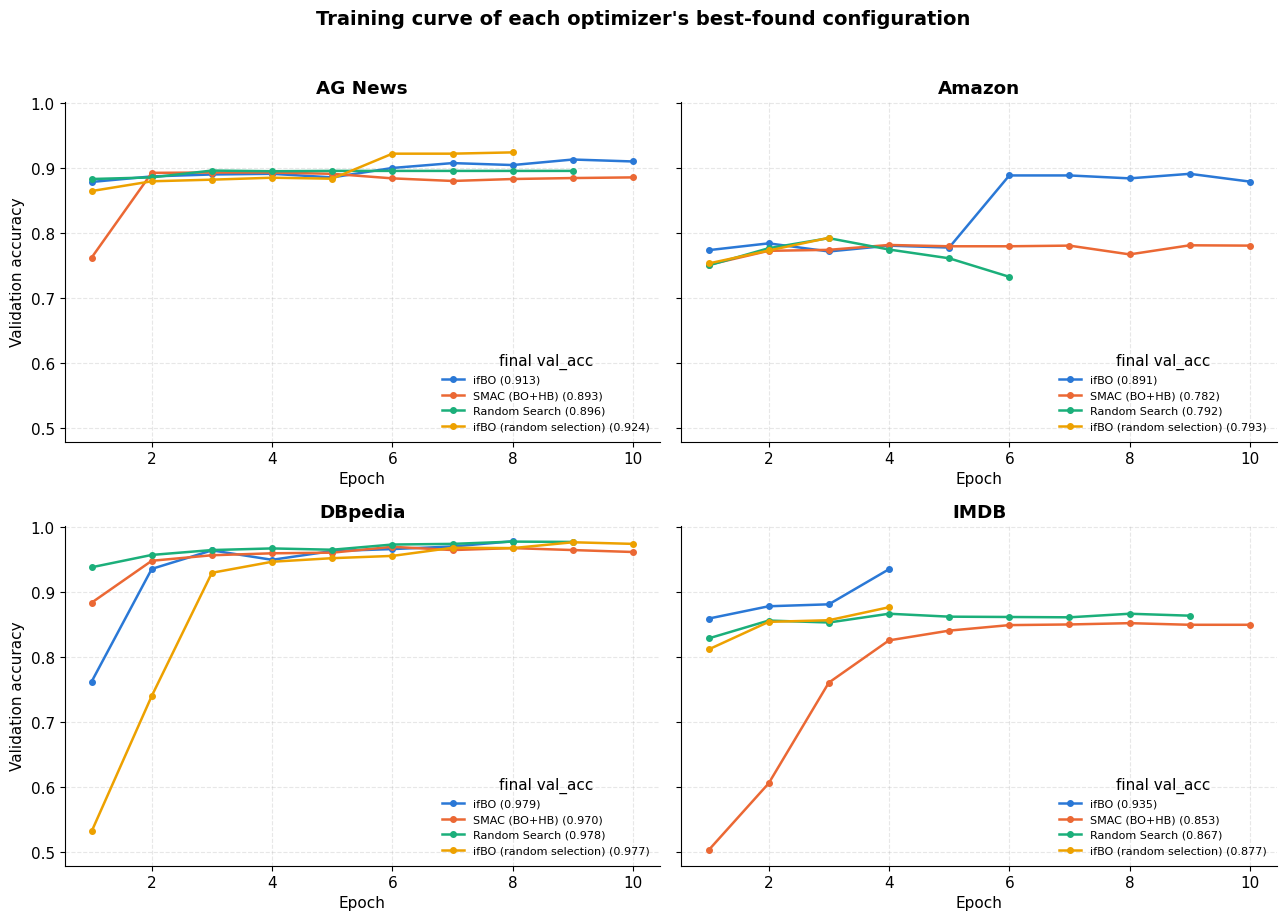

In [10]:
def best_trial(ds_key: str, opt_key: str) -> dict:
    return min(raw_trials[(ds_key, opt_key)], key=lambda t: t["val_error"])


fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
for ax, (ds_key, ds_label) in zip(axes.flat, DATASETS.items()):
    for opt_key, opt_label in OPTIMIZERS.items():
        t = best_trial(ds_key, opt_key)
        epochs = [e["epoch"] for e in t["epoch_history"]]
        accs = [e["val_accuracy"] for e in t["epoch_history"]]
        ax.plot(
            epochs, accs, "o-", color=COLORS[opt_key], markersize=4, linewidth=1.8,
            label=f"{opt_label} ({1 - t['val_error']:.3f})",
        )
    ax.set_title(ds_label, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(loc="lower right", fontsize=8, frameon=False, title="final val_acc")

for ax in axes[:, 0]:
    ax.set_ylabel("Validation accuracy")

fig.suptitle("Training curve of each optimizer's best-found configuration", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 8. Total search wallclock time

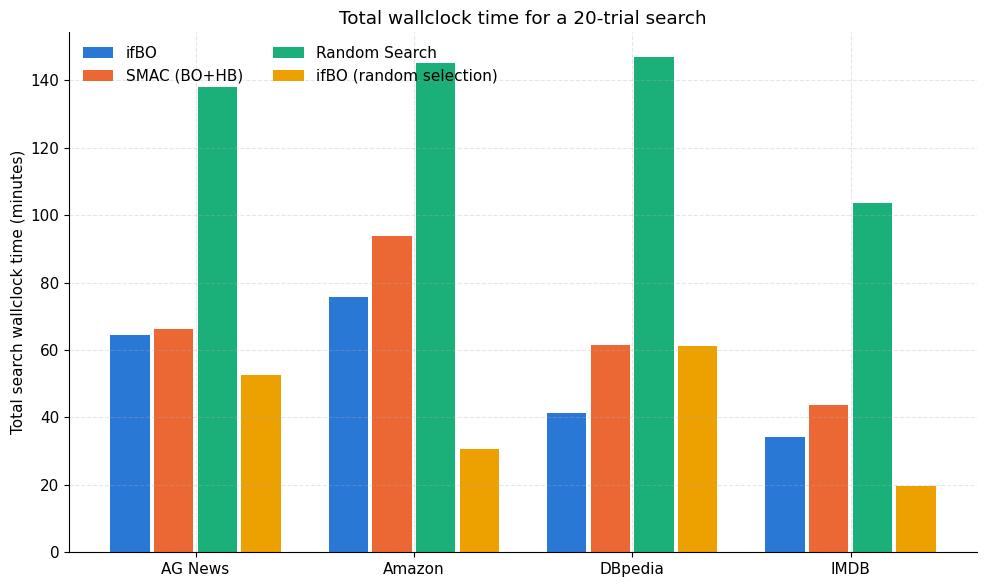

In [11]:
total_time = (
    trials_df.groupby(["dataset", "optimizer"])["wallclock_s"].max().unstack("optimizer")[list(OPTIMIZERS)]
    / 60.0
)
total_time.index = total_time.index.map(DATASETS)
total_time.columns = total_time.columns.map(OPTIMIZERS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(total_time.index))
width = 0.8 / len(OPTIMIZERS)
for i, (opt_key, opt_label) in enumerate(OPTIMIZERS.items()):
    vals = total_time[opt_label]
    ax.bar(x + i * width - 0.4 + width / 2, vals, width=width * 0.9, color=COLORS[opt_key], label=opt_label)

ax.set_xticks(x)
ax.set_xticklabels(total_time.index)
ax.set_ylabel("Total search wallclock time (minutes)")
ax.set_title("Total wallclock time for a 20-trial search")
ax.legend(loc="upper left", ncol=2, frameon=False)
fig.tight_layout()
plt.show()

## Summary

In [12]:
summary = final_acc.copy()
summary["best_optimizer"] = summary.idxmax(axis=1)
summary

optimizer,ifBO,SMAC (BO+HB),Random Search,ifBO (random selection),best_optimizer
dataset,,,,,
AG News,0.9135,0.8935,0.8965,0.9245,ifBO (random selection)
Amazon,0.8915,0.7820,0.7925,0.7930,ifBO
DBpedia,0.9785,0.9700,0.9780,0.9770,ifBO
IMDB,0.9355,0.8525,0.8670,0.8770,ifBO
